In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Project paths
BASE_DIR = os.path.abspath("..")

RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Raw data directory:", RAW_DATA_DIR)

Base directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting
Raw data directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\raw


In [2]:
calendar_path = os.path.join(RAW_DATA_DIR, "calendar.csv")
sales_path = os.path.join(RAW_DATA_DIR, "sales_train_validation.csv")
prices_path = os.path.join(RAW_DATA_DIR, "sell_prices.csv")

calendar_df = pd.read_csv(calendar_path)
sales_df = pd.read_csv(sales_path)
prices_df = pd.read_csv(prices_path)

print("Calendar shape:", calendar_df.shape)
print("Sales shape:", sales_df.shape)
print("Prices shape:", prices_df.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)
Prices shape: (6841121, 4)


In [3]:
print("Calendar columns:")
print(calendar_df.columns.tolist())

print("\nSales columns:")
print(sales_df.columns[:15].tolist())
print("...")
print(sales_df.columns[-5:].tolist())

print("\nPrices columns:")
print(prices_df.columns.tolist())

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9']
...
['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

Prices columns:
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']


## 3. Data Preprocessing

The sales dataset is currently in wide format, where each day is represented as a separate column such as `d_1`, `d_2`, ..., `d_1913`.

For time series forecasting, we need to convert this into long format where each row represents sales for one item on one day.

To keep the first version simple and computationally efficient, we will start with one Walmart store: `CA_1`.

In [4]:
# Select one store for the first baseline version
SELECTED_STORE = "CA_1"

store_sales_df = sales_df[sales_df["store_id"] == SELECTED_STORE].copy()

print("Selected store:", SELECTED_STORE)
print("Store sales shape:", store_sales_df.shape)

store_sales_df.head()

Selected store: CA_1
Store sales shape: (3049, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,...,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,...,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


In [5]:
# Identify all daily sales columns
day_columns = [col for col in store_sales_df.columns if col.startswith("d_")]

print("Number of day columns:", len(day_columns))
print("First 5 day columns:", day_columns[:5])
print("Last 5 day columns:", day_columns[-5:])

Number of day columns: 1913
First 5 day columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5 day columns: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [6]:
id_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

store_sales_long_df = store_sales_df.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="d",
    value_name="sales"
)

print("Long format shape:", store_sales_long_df.shape)
store_sales_long_df.head()

Long format shape: (5832737, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [7]:
store_sales_long_df = store_sales_long_df.merge(
    calendar_df[
        [
            "d",
            "date",
            "wm_yr_wk",
            "weekday",
            "wday",
            "month",
            "year",
            "event_name_1",
            "event_type_1",
            "snap_CA"
        ]
    ],
    on="d",
    how="left"
)

store_sales_long_df["date"] = pd.to_datetime(store_sales_long_df["date"])

print("Shape after calendar merge:", store_sales_long_df.shape)

store_sales_long_df.head()

Shape after calendar merge: (5832737, 17)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0


## 4. Category-Level Aggregation

For the first forecasting version, we aggregate item-level sales into category-level daily demand.

This helps us start with a clean business-level forecast instead of directly modeling thousands of individual products.

For store `CA_1`, we will create one daily time series for each category:

- FOODS
- HOBBIES
- HOUSEHOLD

In [8]:
category_daily_df = (
    store_sales_long_df
    .groupby(["date", "cat_id"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        snap_CA=("snap_CA", "max")
    )
)

print("Category daily shape:", category_daily_df.shape)
category_daily_df.head()

Category daily shape: (5739, 4)


,date,cat_id,sales,snap_CA
0,2011-01-29,FOODS,3239,0
1,2011-01-29,HOBBIES,556,0
2,2011-01-29,HOUSEHOLD,542,0
3,2011-01-30,FOODS,3137,0
4,2011-01-30,HOBBIES,498,0


In [9]:
category_daily_df["cat_id"].unique()

<StringArray>
['FOODS', 'HOBBIES', 'HOUSEHOLD']
Length: 3, dtype: str

In [10]:
category_daily_df[category_daily_df["cat_id"] == "FOODS"].head()

,date,cat_id,sales,snap_CA
0,2011-01-29,FOODS,3239,0
3,2011-01-30,FOODS,3137,0
6,2011-01-31,FOODS,2008,0
9,2011-02-01,FOODS,2258,1
12,2011-02-02,FOODS,2032,1


In [11]:
category_processed_path = os.path.join(PROCESSED_DATA_DIR, "category_daily_sales_CA_1.csv")

category_daily_df.to_csv(category_processed_path, index=False)

print("Saved processed file to:")
print(category_processed_path)

Saved processed file to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\category_daily_sales_CA_1.csv


## 5. Exploratory Data Analysis

Before building the forecasting model, we first analyze the category-level sales patterns.

We will check:

1. Overall sales trend
2. Category-wise demand difference
3. Weekly seasonality
4. Sales behavior around SNAP days

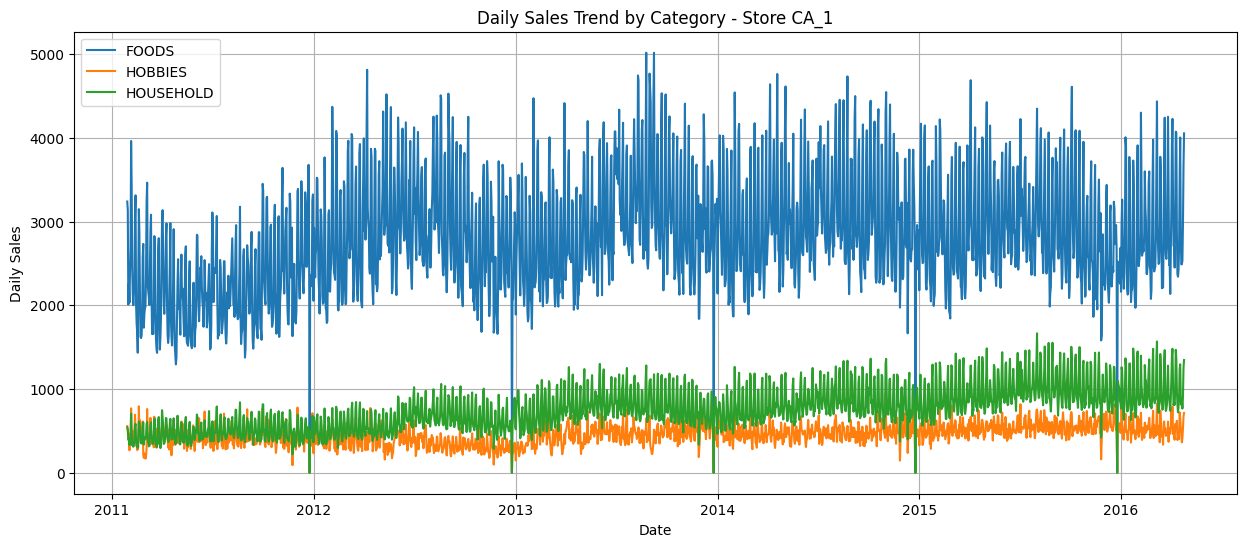

In [13]:
plt.figure(figsize=(15, 6))

for category in category_daily_df["cat_id"].unique():
    temp_df = category_daily_df[category_daily_df["cat_id"] == category]
    plt.plot(temp_df["date"], temp_df["sales"], label=category)

plt.title("Daily Sales Trend by Category - Store CA_1")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
category_summary_df = (
    category_daily_df
    .groupby("cat_id", as_index=False)
    .agg(
        avg_daily_sales=("sales", "mean"),
        median_daily_sales=("sales", "median"),
        min_daily_sales=("sales", "min"),
        max_daily_sales=("sales", "max"),
        total_sales=("sales", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

category_summary_df

,cat_id,avg_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,total_sales
0,FOODS,2812.769472,2710.0,0,5016,5380828
2,HOUSEHOLD,753.115525,729.0,0,1665,1440710
1,HOBBIES,458.273915,459.0,0,953,876678


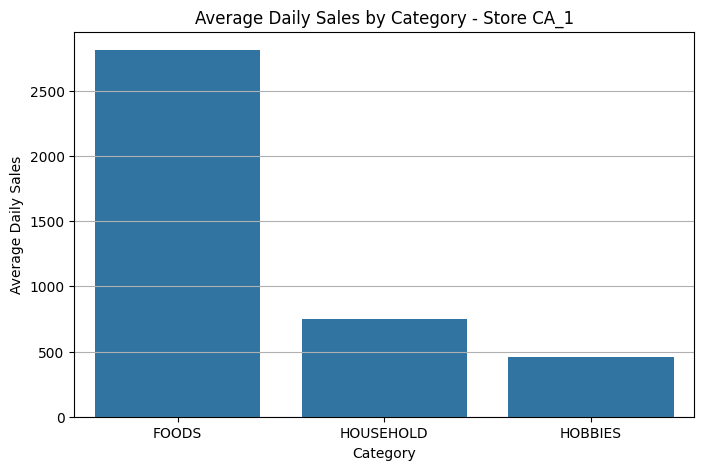

In [21]:

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_summary_df,
    x="cat_id",
    y="avg_daily_sales"
)

plt.title("Average Daily Sales by Category - Store CA_1")
plt.xlabel("Category")
plt.ylabel("Average Daily Sales")
plt.grid(axis="y")
plt.show()

In [16]:
snap_summary_df = (
    category_daily_df
    .groupby(["cat_id", "snap_CA"], as_index=False)
    .agg(avg_sales=("sales", "mean"))
)

snap_summary_df

,cat_id,snap_CA,avg_sales
0,FOODS,0,2705.162899
1,FOODS,1,3031.911111
2,HOBBIES,0,451.502728
3,HOBBIES,1,472.063492
4,HOUSEHOLD,0,740.434918
5,HOUSEHOLD,1,778.939683


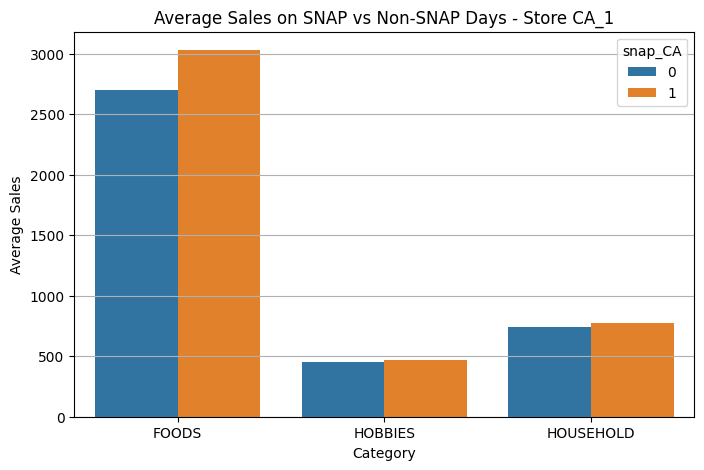

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=snap_summary_df,
    x="cat_id",
    y="avg_sales",
    hue="snap_CA"
)

plt.title("Average Sales on SNAP vs Non-SNAP Days - Store CA_1")
plt.xlabel("Category")
plt.ylabel("Average Sales")
plt.grid(axis="y")
plt.show()

## 6. Prepare Category Time Series for Forecasting

We will start SARIMAX modeling with the `FOODS` category because it has the highest sales volume and clearer demand patterns.

For SARIMAX, the data should be a clean time series with:

- date as index
- daily sales as target variable
- regular daily frequency

In [22]:
SELECTED_CATEGORY = "FOODS"

foods_df = category_daily_df[
    category_daily_df["cat_id"] == SELECTED_CATEGORY
].copy()

foods_df = foods_df.sort_values("date")

foods_df.head()

,date,cat_id,sales,snap_CA
0,2011-01-29,FOODS,3239,0
3,2011-01-30,FOODS,3137,0
6,2011-01-31,FOODS,2008,0
9,2011-02-01,FOODS,2258,1
12,2011-02-02,FOODS,2032,1


In [23]:
foods_ts = foods_df[["date", "sales", "snap_CA"]].copy()

foods_ts = foods_ts.set_index("date")
foods_ts = foods_ts.asfreq("D")

print("FOODS time series shape:", foods_ts.shape)
print("Missing values:")
print(foods_ts.isnull().sum())

foods_ts.head()

FOODS time series shape: (1913, 2)
Missing values:
sales      0
snap_CA    0
dtype: int64


,sales,snap_CA
date,,
2011-01-29,3239,0
2011-01-30,3137,0
2011-01-31,2008,0
2011-02-01,2258,1
2011-02-02,2032,1


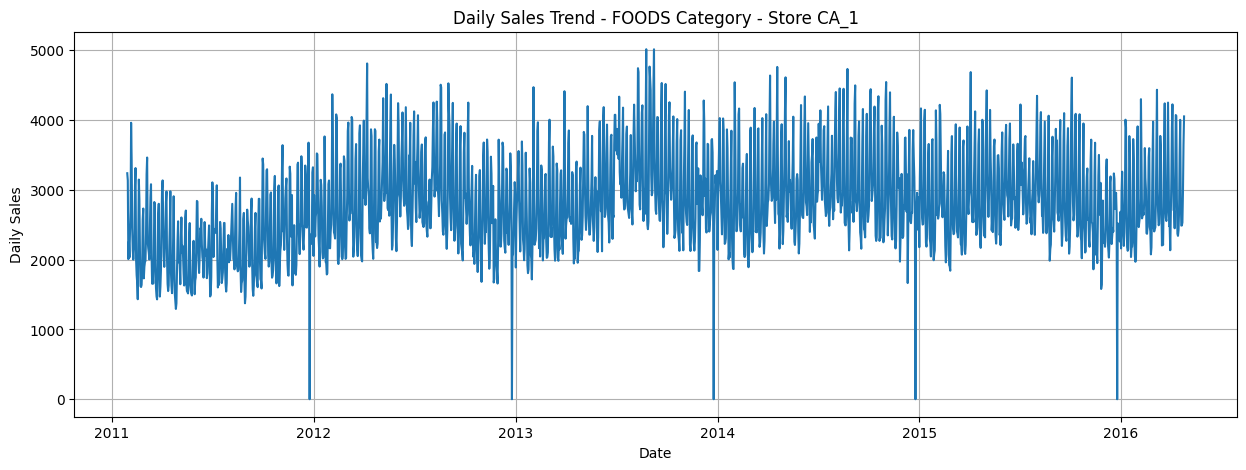

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(foods_ts.index, foods_ts["sales"])

plt.title("Daily Sales Trend - FOODS Category - Store CA_1")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.grid(True)
plt.show()

In [25]:
foods_ts["sales"].describe()

count    1913.000000
mean     2812.769472
std       700.751677
min         0.000000
25%      2323.000000
50%      2710.000000
75%      3265.000000
max      5016.000000
Name: sales, dtype: float64

In [26]:
foods_ts.shape
foods_ts.isnull().sum()
foods_ts["sales"].describe()

count    1913.000000
mean     2812.769472
std       700.751677
min         0.000000
25%      2323.000000
50%      2710.000000
75%      3265.000000
max      5016.000000
Name: sales, dtype: float64

## 7. Train-Test Split

The M5 competition forecasts demand for the next 28 days.

So for our baseline setup, we will use:

- Training data: all days except the last 28 days
- Test data: last 28 days

The model will learn from historical sales and predict the final 28 days.

In [27]:
FORECAST_HORIZON = 28

train_df = foods_ts.iloc[:-FORECAST_HORIZON].copy()
test_df = foods_ts.iloc[-FORECAST_HORIZON:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nTest date range:")
print(test_df.index.min(), "to", test_df.index.max())

Train shape: (1885, 2)
Test shape: (28, 2)

Train date range:
2011-01-29 00:00:00 to 2016-03-27 00:00:00

Test date range:
2016-03-28 00:00:00 to 2016-04-24 00:00:00


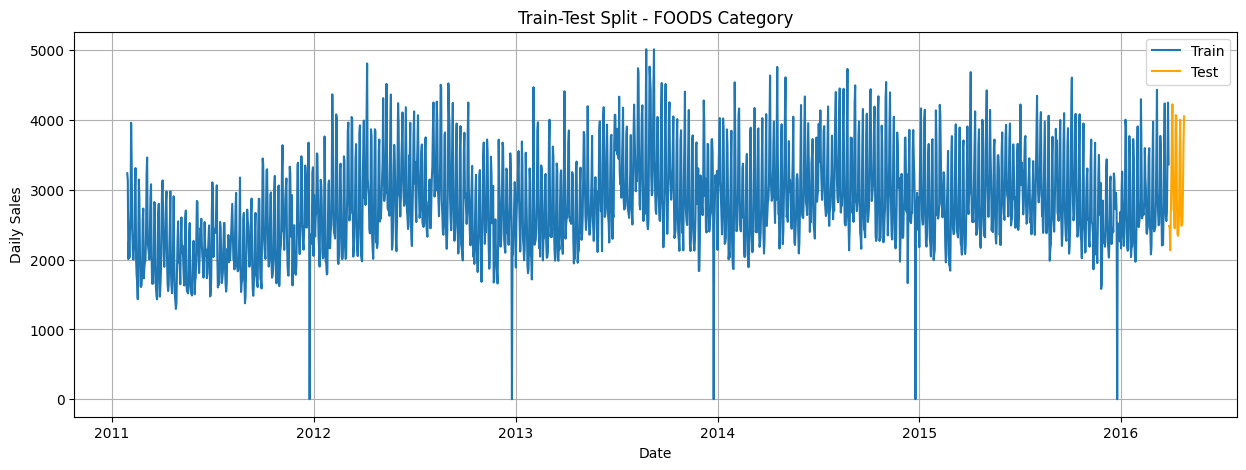

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(train_df.index, train_df["sales"], label="Train")
plt.plot(test_df.index, test_df["sales"], label="Test", color="orange")

plt.title("Train-Test Split - FOODS Category")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
y_train = train_df["sales"]
y_test = test_df["sales"]

X_train = train_df[["snap_CA"]]
X_test = test_df[["snap_CA"]]

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

y_train: (1885,)
y_test: (28,)
X_train: (1885, 1)
X_test: (28, 1)


## 8. Baseline Forecasting

Before training SARIMAX, we build simple baseline models.

A forecasting model is only useful if it performs better than simple assumptions.

We will compare SARIMAX against:

1. Naive forecast: uses the last observed sales value
2. 7-day moving average forecast: uses the average sales of the last 7 training days

In [30]:
def evaluate_forecast(y_true, y_pred, model_name):
    """
    Evaluate forecast using MAE, RMSE, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Avoid division by zero for MAPE
    y_true_safe = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [31]:
last_observed_value = y_train.iloc[-1]

naive_forecast = np.repeat(last_observed_value, FORECAST_HORIZON)

naive_results = evaluate_forecast(
    y_true=y_test.values,
    y_pred=naive_forecast,
    model_name="Naive Forecast"
)

naive_results

{'model': 'Naive Forecast',
 'MAE': 664.6428571428571,
 'RMSE': np.float64(722.8594508715271),
 'MAPE': np.float64(24.00190605556048)}

In [32]:
last_7_day_avg = y_train.iloc[-7:].mean()

moving_avg_forecast = np.repeat(last_7_day_avg, FORECAST_HORIZON)

moving_avg_results = evaluate_forecast(
    y_true=y_test.values,
    y_pred=moving_avg_forecast,
    model_name="7-Day Moving Average"
)

moving_avg_results

{'model': '7-Day Moving Average',
 'MAE': 566.2857142857143,
 'RMSE': np.float64(640.290726378037),
 'MAPE': np.float64(19.143962968229133)}

In [33]:
baseline_results_df = pd.DataFrame([
    naive_results,
    moving_avg_results
])

baseline_results_df

,model,MAE,RMSE,MAPE
0,Naive Forecast,664.642857,722.859451,24.001906
1,7-Day Moving Average,566.285714,640.290726,19.143963


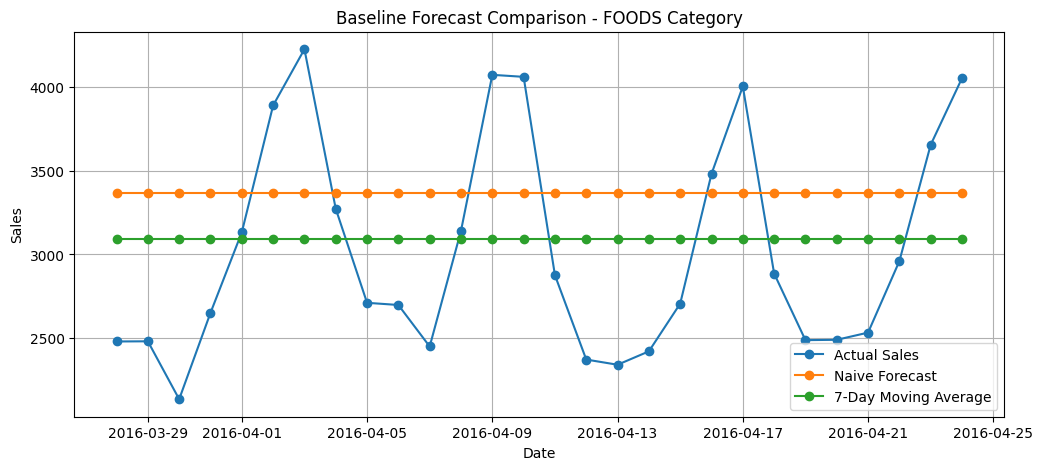

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test.values, label="Actual Sales", marker="o")
plt.plot(y_test.index, naive_forecast, label="Naive Forecast", marker="o")
plt.plot(y_test.index, moving_avg_forecast, label="7-Day Moving Average", marker="o")

plt.title("Baseline Forecast Comparison - FOODS Category")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 9. SARIMAX Modeling

Now we build our first SARIMAX model.

SARIMAX is useful for time series forecasting because it can model:

- trend
- autoregressive behavior
- moving average behavior
- seasonality
- external variables such as SNAP days

For the first model, we use weekly seasonality with a 7-day seasonal period.

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [36]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

print(sarimax_result.summary())

c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1885
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -13346.529
Date:                           Sun, 07 Jun 2026   AIC                          26705.058
Time:                                   15:48:25   BIC                          26738.254
Sample:                               01-29-2011   HQIC                         26717.289
                                    - 03-27-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
snap_CA      269.3025     20.825     12.932      0.000     228.487     310.118
ar.L1          0.2824      0.016     18.147

In [37]:
sarimax_forecast_result = sarimax_result.get_forecast(
    steps=FORECAST_HORIZON,
    exog=X_test
)

sarimax_forecast = sarimax_forecast_result.predicted_mean

sarimax_forecast.head()

2016-03-28    2681.097252
2016-03-29    2463.811326
2016-03-30    2446.986011
2016-03-31    2457.114365
2016-04-01    3177.073705
Freq: D, Name: predicted_mean, dtype: float64

In [38]:
sarimax_results = evaluate_forecast(
    y_true=y_test.values,
    y_pred=sarimax_forecast.values,
    model_name="SARIMAX (1,1,1)(1,1,1,7)"
)

sarimax_results

{'model': 'SARIMAX (1,1,1)(1,1,1,7)',
 'MAE': 117.30883785451817,
 'RMSE': np.float64(148.33084933973961),
 'MAPE': np.float64(3.968290821882787)}

In [39]:
all_results_df = pd.DataFrame([
    naive_results,
    moving_avg_results,
    sarimax_results
])

all_results_df.sort_values("MAPE")

,model,MAE,RMSE,MAPE
2,"SARIMAX (1,1,1)(1,1,1,7)",117.308838,148.330849,3.968291
1,7-Day Moving Average,566.285714,640.290726,19.143963
0,Naive Forecast,664.642857,722.859451,24.001906


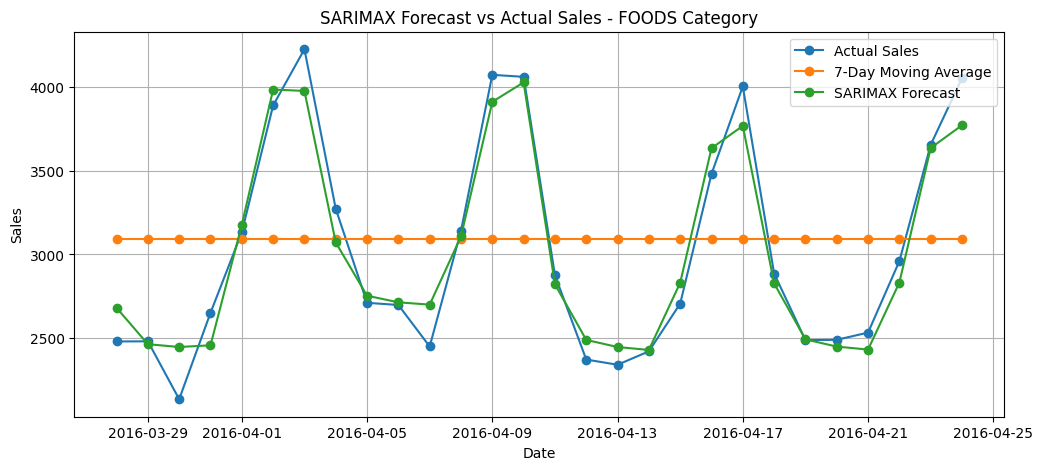

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test.values, label="Actual Sales", marker="o")
plt.plot(y_test.index, moving_avg_forecast, label="7-Day Moving Average", marker="o")
plt.plot(y_test.index, sarimax_forecast.values, label="SARIMAX Forecast", marker="o")

plt.title("SARIMAX Forecast vs Actual Sales - FOODS Category")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 10. Model Diagnostics

After training SARIMAX, we check the residuals.

Residuals are the errors left after the model makes predictions.

A good forecasting model should have residuals that look random, with no strong pattern left.

In [41]:
sarimax_residuals = sarimax_result.resid

print("Residuals shape:", sarimax_residuals.shape)
sarimax_residuals.head()

Residuals shape: (1885,)


date
2011-01-29    3239.000000
2011-01-30    -406.940085
2011-01-31   -1170.106520
2011-02-01     103.336433
2011-02-02    -203.229909
Freq: D, dtype: float64

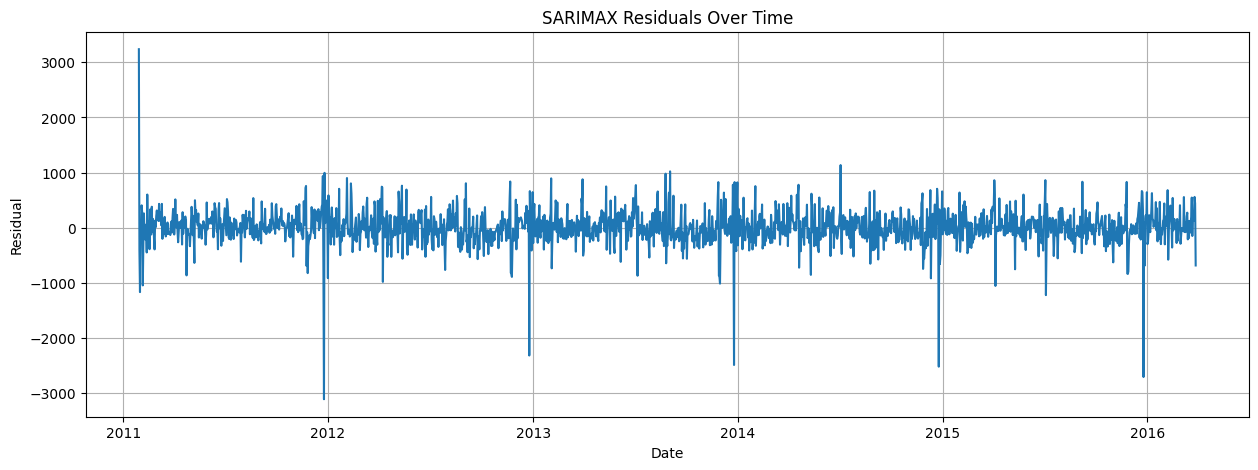

In [42]:
plt.figure(figsize=(15, 5))

plt.plot(sarimax_residuals)

plt.title("SARIMAX Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

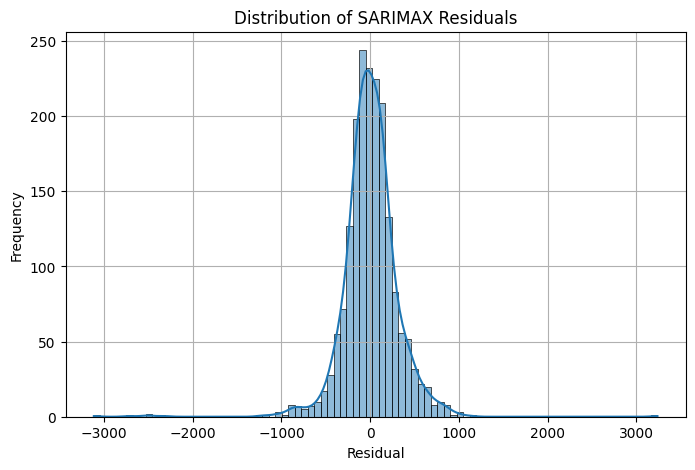

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(sarimax_residuals, kde=True)

plt.title("Distribution of SARIMAX Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

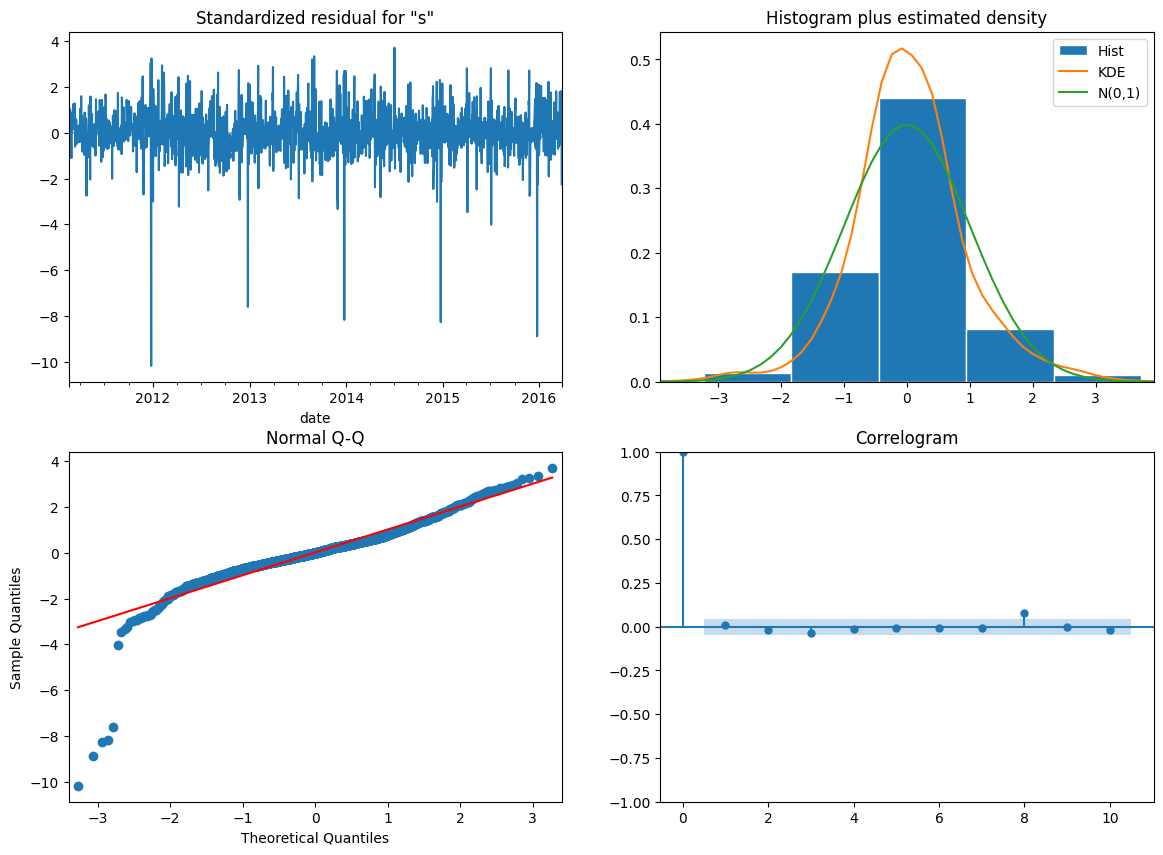

In [44]:
sarimax_result.plot_diagnostics(figsize=(14, 10))
plt.show()

In [45]:
sarimax_forecast_df = pd.DataFrame({
    "date": y_test.index,
    "actual_sales": y_test.values,
    "sarimax_forecast": sarimax_forecast.values,
    "moving_avg_forecast": moving_avg_forecast,
    "naive_forecast": naive_forecast
})

forecast_output_path = os.path.join(OUTPUTS_DIR, "foods_sarimax_forecast_CA_1.csv")

sarimax_forecast_df.to_csv(forecast_output_path, index=False)

print("Forecast saved to:")
print(forecast_output_path)

sarimax_forecast_df.head()

Forecast saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\foods_sarimax_forecast_CA_1.csv


,date,actual_sales,sarimax_forecast,moving_avg_forecast,naive_forecast
0,2016-03-28,2480,2681.097252,3091.0,3366
1,2016-03-29,2481,2463.811326,3091.0,3366
2,2016-03-30,2135,2446.986011,3091.0,3366
3,2016-03-31,2651,2457.114365,3091.0,3366
4,2016-04-01,3132,3177.073705,3091.0,3366


## 11. SARIMAX Parameter Tuning

The first SARIMAX model performed well, but it showed a convergence warning.

To improve stability and compare performance, we will test multiple SARIMAX parameter combinations.

We will compare each model using:

- AIC: model fit quality
- MAE: average absolute forecast error
- RMSE: penalizes larger errors
- MAPE: percentage forecast error

In [46]:
def train_evaluate_sarimax(order, seasonal_order, model_name):
    """
    Train SARIMAX model and evaluate it on the 28-day test set.
    """
    try:
        model = SARIMAX(
            y_train,
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(disp=False, maxiter=100)

        forecast_result = result.get_forecast(
            steps=FORECAST_HORIZON,
            exog=X_test
        )

        forecast_values = forecast_result.predicted_mean

        metrics = evaluate_forecast(
            y_true=y_test.values,
            y_pred=forecast_values.values,
            model_name=model_name
        )

        metrics["AIC"] = result.aic
        metrics["order"] = order
        metrics["seasonal_order"] = seasonal_order
        metrics["converged"] = result.mle_retvals.get("converged", None)

        return metrics, result, forecast_values

    except Exception as e:
        print(f"Model failed: {model_name}")
        print("Error:", e)
        return None, None, None

In [47]:
sarimax_configs = [
    {
        "model_name": "SARIMAX (1,1,1)(1,1,1,7)",
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "model_name": "SARIMAX (1,1,0)(1,1,1,7)",
        "order": (1, 1, 0),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "model_name": "SARIMAX (0,1,1)(1,1,1,7)",
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "model_name": "SARIMAX (1,1,1)(0,1,1,7)",
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    },
    {
        "model_name": "SARIMAX (1,1,1)(1,1,0,7)",
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 0, 7)
    }
]

In [48]:
tuning_results = []
trained_models = {}
forecast_outputs = {}

for config in sarimax_configs:
    print("Training:", config["model_name"])

    metrics, result, forecast_values = train_evaluate_sarimax(
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        model_name=config["model_name"]
    )

    if metrics is not None:
        tuning_results.append(metrics)
        trained_models[config["model_name"]] = result
        forecast_outputs[config["model_name"]] = forecast_values

        print("Done:", config["model_name"])
        print("MAPE:", round(metrics["MAPE"], 2), "%")
        print("Converged:", metrics["converged"])
        print("-" * 50)

Training: SARIMAX (1,1,1)(1,1,1,7)
Done: SARIMAX (1,1,1)(1,1,1,7)
MAPE: 4.1 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1,1,0)(1,1,1,7)
Done: SARIMAX (1,1,0)(1,1,1,7)
MAPE: 8.46 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0,1,1)(1,1,1,7)
Done: SARIMAX (0,1,1)(1,1,1,7)
MAPE: 5.54 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1,1,1)(0,1,1,7)
Done: SARIMAX (1,1,1)(0,1,1,7)
MAPE: 4.26 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1,1,1)(1,1,0,7)
Done: SARIMAX (1,1,1)(1,1,0,7)
MAPE: 7.93 %
Converged: True
--------------------------------------------------


In [49]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values("MAPE")

tuning_results_df

,model,MAE,RMSE,MAPE,AIC,order,seasonal_order,converged
0,"SARIMAX (1,1,1)(1,1,1,7)",119.953486,148.827865,4.096004,26697.407221,"(1, 1, 1)","(1, 1, 1, 7)",True
3,"SARIMAX (1,1,1)(0,1,1,7)",121.724950,151.338401,4.262989,26734.645413,"(1, 1, 1)","(0, 1, 1, 7)",True
2,"SARIMAX (0,1,1)(1,1,1,7)",153.315076,190.131366,5.538000,26817.877713,"(0, 1, 1)","(1, 1, 1, 7)",True
4,"SARIMAX (1,1,1)(1,1,0,7)",244.613556,292.248883,7.925115,27161.600391,"(1, 1, 1)","(1, 1, 0, 7)",True
1,"SARIMAX (1,1,0)(1,1,1,7)",257.962499,286.911687,8.461297,27223.404272,"(1, 1, 0)","(1, 1, 1, 7)",True


## 12. Best Model Selection

After testing multiple SARIMAX configurations, we select the model with the lowest MAPE.

The best model is then used as the final forecasting model for the FOODS category.

In [50]:
best_model_row = tuning_results_df.iloc[0]

best_model_name = best_model_row["model"]
best_order = best_model_row["order"]
best_seasonal_order = best_model_row["seasonal_order"]

print("Best model:", best_model_name)
print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)
print("Best MAPE:", round(best_model_row["MAPE"], 2), "%")
print("Best AIC:", round(best_model_row["AIC"], 2))

Best model: SARIMAX (1,1,1)(1,1,1,7)
Best order: (1, 1, 1)
Best seasonal order: (1, 1, 1, 7)
Best MAPE: 4.1 %
Best AIC: 26697.41


In [51]:
best_sarimax_result = trained_models[best_model_name]
best_sarimax_forecast = forecast_outputs[best_model_name]

best_sarimax_forecast.head()

2016-03-28    2680.421138
2016-03-29    2458.876473
2016-03-30    2440.470683
2016-03-31    2451.429716
2016-04-01    3227.168719
Freq: D, Name: predicted_mean, dtype: float64

In [52]:
final_results_df = pd.concat(
    [
        baseline_results_df,
        tuning_results_df[["model", "MAE", "RMSE", "MAPE"]]
    ],
    ignore_index=True
)

final_results_df = final_results_df.sort_values("MAPE")

final_results_df

,model,MAE,RMSE,MAPE
2,"SARIMAX (1,1,1)(1,1,1,7)",119.953486,148.827865,4.096004
3,"SARIMAX (1,1,1)(0,1,1,7)",121.724950,151.338401,4.262989
4,"SARIMAX (0,1,1)(1,1,1,7)",153.315076,190.131366,5.538000
5,"SARIMAX (1,1,1)(1,1,0,7)",244.613556,292.248883,7.925115
6,"SARIMAX (1,1,0)(1,1,1,7)",257.962499,286.911687,8.461297
1,7-Day Moving Average,566.285714,640.290726,19.143963
0,Naive Forecast,664.642857,722.859451,24.001906


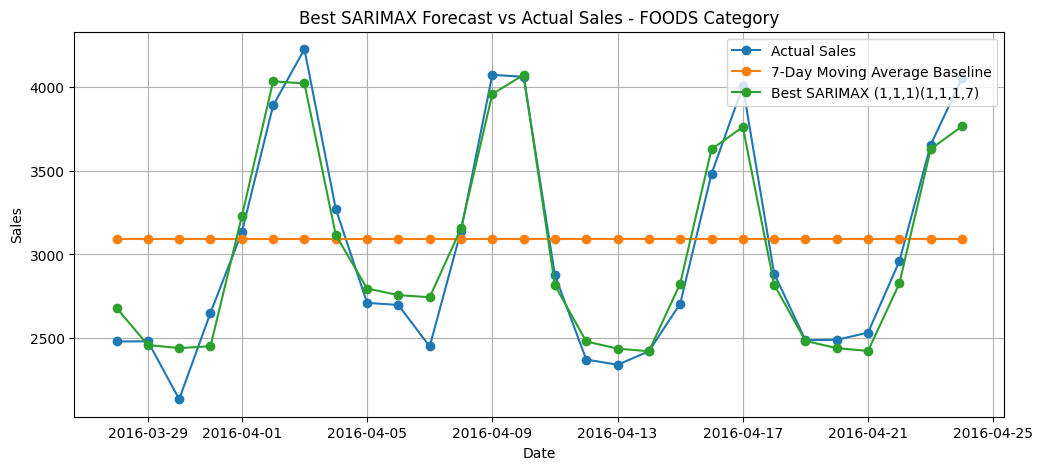

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test.values, label="Actual Sales", marker="o")
plt.plot(y_test.index, moving_avg_forecast, label="7-Day Moving Average Baseline", marker="o")
plt.plot(y_test.index, best_sarimax_forecast.values, label=f"Best {best_model_name}", marker="o")

plt.title("Best SARIMAX Forecast vs Actual Sales - FOODS Category")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
final_forecast_df = pd.DataFrame({
    "date": y_test.index,
    "category": SELECTED_CATEGORY,
    "actual_sales": y_test.values,
    "best_sarimax_forecast": best_sarimax_forecast.values,
    "moving_avg_forecast": moving_avg_forecast,
    "naive_forecast": naive_forecast
})

final_forecast_path = os.path.join(
    OUTPUTS_DIR,
    "final_foods_sarimax_forecast_CA_1.csv"
)

final_forecast_df.to_csv(final_forecast_path, index=False)

print("Final forecast saved to:")
print(final_forecast_path)

final_forecast_df.head()

Final forecast saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_foods_sarimax_forecast_CA_1.csv


,date,category,actual_sales,best_sarimax_forecast,moving_avg_forecast,naive_forecast
0,2016-03-28,FOODS,2480,2680.421138,3091.0,3366
1,2016-03-29,FOODS,2481,2458.876473,3091.0,3366
2,2016-03-30,FOODS,2135,2440.470683,3091.0,3366
3,2016-03-31,FOODS,2651,2451.429716,3091.0,3366
4,2016-04-01,FOODS,3132,3227.168719,3091.0,3366


In [55]:
import joblib

best_model_path = os.path.join(
    MODELS_DIR,
    "best_sarimax_foods_CA_1.pkl"
)

joblib.dump(best_sarimax_result, best_model_path)

print("Best model saved to:")
print(best_model_path)

Best model saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_foods_CA_1.pkl


## 13. Business Interpretation

The SARIMAX model significantly outperformed the simple baseline models.

The best SARIMAX model achieved a MAPE of around 4.10%, compared to 19.14% for the 7-day moving average baseline and 24.00% for the naive forecast.

This means the SARIMAX model is much better at capturing the weekly demand pattern in the FOODS category.

The model also uses SNAP as an external variable, which helps explain sales uplift during SNAP benefit days.

## 14. Business Recommendations

Based on the category-level forecasting results for store CA_1:

1. FOODS should be treated as the highest-priority category because it has the highest sales volume and strongest demand movement.

2. Weekly seasonality is clearly important. Inventory planning should account for recurring weekly sales patterns instead of using flat average demand.

3. SNAP days show higher average sales, especially for FOODS. Store teams should plan extra stock availability around SNAP periods.

4. The SARIMAX model can be used as a first demand-planning layer for short-term 28-day forecasting.

5. For production use, the same modeling approach should be repeated across HOUSEHOLD and HOBBIES categories, then extended to department, store, and item-level forecasting.

In [56]:
project_summary = {
    "store": SELECTED_STORE,
    "category": SELECTED_CATEGORY,
    "forecast_horizon_days": FORECAST_HORIZON,
    "best_model": best_model_name,
    "best_order": best_order,
    "best_seasonal_order": best_seasonal_order,
    "best_MAE": best_model_row["MAE"],
    "best_RMSE": best_model_row["RMSE"],
    "best_MAPE": best_model_row["MAPE"],
    "best_AIC": best_model_row["AIC"]
}

project_summary_df = pd.DataFrame([project_summary])
project_summary_df

,store,category,forecast_horizon_days,best_model,best_order,best_seasonal_order,best_MAE,best_RMSE,best_MAPE,best_AIC
0,CA_1,FOODS,28,"SARIMAX (1,1,1)(1,1,1,7)","(1, 1, 1)","(1, 1, 1, 7)",119.953486,148.827865,4.096004,26697.407221


In [57]:
summary_output_path = os.path.join(
    OUTPUTS_DIR,
    "foods_sarimax_project_summary_CA_1.csv"
)

project_summary_df.to_csv(summary_output_path, index=False)

print("Project summary saved to:")
print(summary_output_path)

Project summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\foods_sarimax_project_summary_CA_1.csv


## 15. Reusable SARIMAX Pipeline for All Categories

So far, we manually trained and evaluated SARIMAX for the FOODS category.

Now we convert the workflow into reusable functions and apply the same forecasting process to all categories:

- FOODS
- HOBBIES
- HOUSEHOLD

This makes the notebook scalable and closer to a real demand-planning workflow.

In [58]:
def prepare_category_timeseries(category_daily_df, category_name):
    """
    Prepare daily time series data for one category.
    """
    category_df = category_daily_df[
        category_daily_df["cat_id"] == category_name
    ].copy()
    
    category_df = category_df.sort_values("date")
    
    category_ts = category_df[["date", "sales", "snap_CA"]].copy()
    category_ts = category_ts.set_index("date")
    category_ts = category_ts.asfreq("D")
    
    return category_ts

In [59]:
def run_category_sarimax_pipeline(
    category_daily_df,
    category_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run complete SARIMAX forecasting pipeline for one category.
    """
    
    category_ts = prepare_category_timeseries(
        category_daily_df=category_daily_df,
        category_name=category_name
    )
    
    train_data = category_ts.iloc[:-forecast_horizon].copy()
    test_data = category_ts.iloc[-forecast_horizon:].copy()
    
    y_train_cat = train_data["sales"]
    y_test_cat = test_data["sales"]
    
    X_train_cat = train_data[["snap_CA"]]
    X_test_cat = test_data[["snap_CA"]]
    
    model = SARIMAX(
        y_train_cat,
        exog=X_train_cat,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_cat
    )
    
    forecast_values = forecast_result.predicted_mean
    
    metrics = evaluate_forecast(
        y_true=y_test_cat.values,
        y_pred=forecast_values.values,
        model_name=f"SARIMAX {order}{seasonal_order} - {category_name}"
    )
    
    metrics["category"] = category_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    
    forecast_df = pd.DataFrame({
        "date": y_test_cat.index,
        "category": category_name,
        "actual_sales": y_test_cat.values,
        "sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [60]:
all_categories = category_daily_df["cat_id"].unique().tolist()

all_category_metrics = []
all_category_forecasts = []
all_category_models = {}

for category in all_categories:
    print("Running SARIMAX for:", category)
    
    metrics, forecast_df, model_result = run_category_sarimax_pipeline(
        category_daily_df=category_daily_df,
        category_name=category,
        forecast_horizon=FORECAST_HORIZON,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7)
    )
    
    all_category_metrics.append(metrics)
    all_category_forecasts.append(forecast_df)
    all_category_models[category] = model_result
    
    print("Done:", category)
    print("MAPE:", round(metrics["MAPE"], 2), "%")
    print("Converged:", metrics["converged"])
    print("-" * 50)

Running SARIMAX for: FOODS
Done: FOODS
MAPE: 4.1 %
Converged: True
--------------------------------------------------
Running SARIMAX for: HOBBIES
Done: HOBBIES
MAPE: 14.02 %
Converged: True
--------------------------------------------------
Running SARIMAX for: HOUSEHOLD
Done: HOUSEHOLD
MAPE: 4.96 %
Converged: True
--------------------------------------------------


In [61]:
all_category_results_df = pd.DataFrame(all_category_metrics)

all_category_results_df = all_category_results_df.sort_values("MAPE")

all_category_results_df

,model,MAE,RMSE,MAPE,category,AIC,order,seasonal_order,converged
0,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS",119.953486,148.827865,4.096004,FOODS,26697.407221,"(1, 1, 1)","(1, 1, 1, 7)",True
2,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - HOUSEHOLD",52.753027,72.495923,4.964332,HOUSEHOLD,22086.522849,"(1, 1, 1)","(1, 1, 1, 7)",True
1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - HOBBIES",78.650912,94.105688,14.022757,HOBBIES,21996.006983,"(1, 1, 1)","(1, 1, 1, 7)",True


## 16. Category-Wise SARIMAX Tuning

The previous step applied the same SARIMAX configuration to all categories.

However, each category can have different demand behavior.

So now we tune SARIMAX separately for each category and select the best model based on MAPE.

In [62]:
category_sarimax_configs = [
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 0),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 0, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    }
]

In [63]:
def tune_sarimax_for_category(
    category_daily_df,
    category_name,
    configs,
    forecast_horizon=28
):
    """
    Tune SARIMAX models for one category and return all results.
    """
    
    category_results = []
    category_models = {}
    category_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"SARIMAX {order}{seasonal_order} - {category_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_category_sarimax_pipeline(
                category_daily_df=category_daily_df,
                category_name=category_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            category_results.append(metrics)
            category_models[model_label] = model_result
            category_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    category_results_df = pd.DataFrame(category_results)
    category_results_df = category_results_df.sort_values("MAPE")
    
    return category_results_df, category_models, category_forecasts

In [64]:
all_tuned_results = []
all_tuned_models = {}
all_tuned_forecasts = {}

for category in all_categories:
    print("=" * 70)
    print("Tuning category:", category)
    print("=" * 70)
    
    category_results_df, category_models, category_forecasts = tune_sarimax_for_category(
        category_daily_df=category_daily_df,
        category_name=category,
        configs=category_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    best_row = category_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_tuned_results.append(best_row)
    all_tuned_models[category] = category_models[best_model_label]
    all_tuned_forecasts[category] = category_forecasts[best_model_label]
    
    print("Best model for", category)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Tuning category: FOODS
Training: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS
Done: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS
MAPE: 4.1 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS
Done: SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS
MAPE: 8.46 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS
Done: SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS
MAPE: 5.54 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS
Done: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS
MAPE: 4.26 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS
Done: SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS
MAPE: 7.93 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS
Done: SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS
MAPE: 5.82 %
Converged: Tr

In [65]:
all_tuned_results_df = pd.DataFrame(all_tuned_results)

all_tuned_results_df = all_tuned_results_df[
    [
        "category",
        "model",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_tuned_results_df

,category,model,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS","(1, 1, 1)","(1, 1, 1, 7)",119.953486,148.827865,4.096004,26697.407221,True
0,HOUSEHOLD,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - HOUSEHOLD","(1, 1, 1)","(1, 1, 1, 7)",52.753027,72.495923,4.964332,22086.522849,True
5,HOBBIES,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBIES","(0, 1, 1)","(0, 1, 1, 7)",77.200629,96.805784,13.469932,22035.004708,True


## 17. Final Tuned Forecasts for All Categories

After tuning SARIMAX separately for each category, we now combine the best forecast outputs.

This gives one final forecast table containing:

- actual sales
- predicted sales
- forecast error
- percentage error
- category name

This table can be used for reporting, dashboarding, and business recommendations.

In [66]:
final_all_category_forecasts_df = pd.concat(
    all_tuned_forecasts.values(),
    ignore_index=True
)

final_all_category_forecasts_df["error"] = (
    final_all_category_forecasts_df["actual_sales"]
    - final_all_category_forecasts_df["sarimax_forecast"]
)

final_all_category_forecasts_df["absolute_error"] = final_all_category_forecasts_df["error"].abs()

final_all_category_forecasts_df["absolute_percentage_error"] = (
    final_all_category_forecasts_df["absolute_error"]
    / final_all_category_forecasts_df["actual_sales"].replace(0, np.nan)
) * 100

final_all_category_forecasts_df.head()

,date,category,actual_sales,sarimax_forecast,error,absolute_error,absolute_percentage_error
0,2016-03-28,FOODS,2480,2680.421138,-200.421138,200.421138,8.081498
1,2016-03-29,FOODS,2481,2458.876473,22.123527,22.123527,0.891718
2,2016-03-30,FOODS,2135,2440.470683,-305.470683,305.470683,14.307760
3,2016-03-31,FOODS,2651,2451.429716,199.570284,199.570284,7.528113
4,2016-04-01,FOODS,3132,3227.168719,-95.168719,95.168719,3.038593


In [67]:
print("Final tuned forecast shape:", final_all_category_forecasts_df.shape)

final_all_category_forecasts_df.groupby("category").agg(
    forecast_days=("date", "count"),
    avg_actual_sales=("actual_sales", "mean"),
    avg_forecast_sales=("sarimax_forecast", "mean"),
    avg_absolute_error=("absolute_error", "mean"),
    avg_percentage_error=("absolute_percentage_error", "mean")
)

Final tuned forecast shape: (84, 7)


,forecast_days,avg_actual_sales,avg_forecast_sales,avg_absolute_error,avg_percentage_error
category,,,,,
FOODS,28,3023.857143,3024.025136,119.953486,4.096004
HOBBIES,28,537.607143,492.748297,77.200629,13.469932
HOUSEHOLD,28,1008.357143,969.018767,52.753027,4.964332


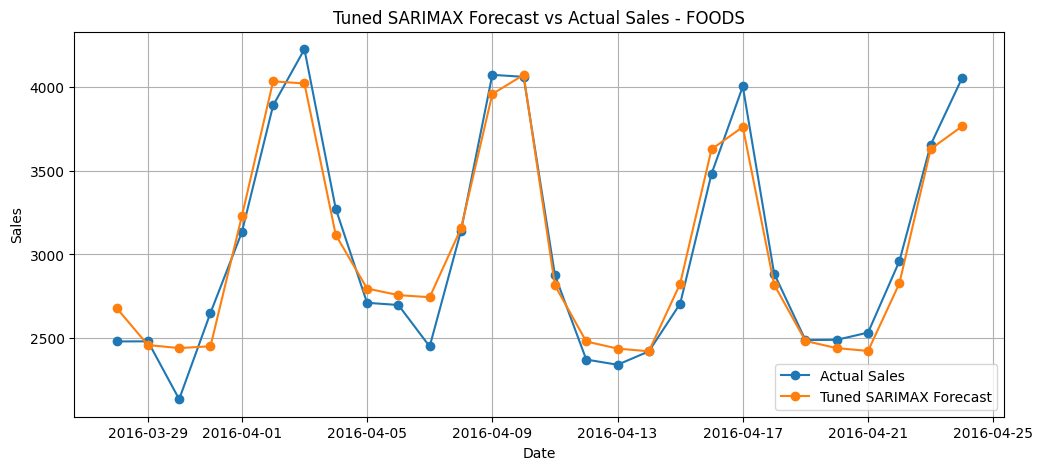

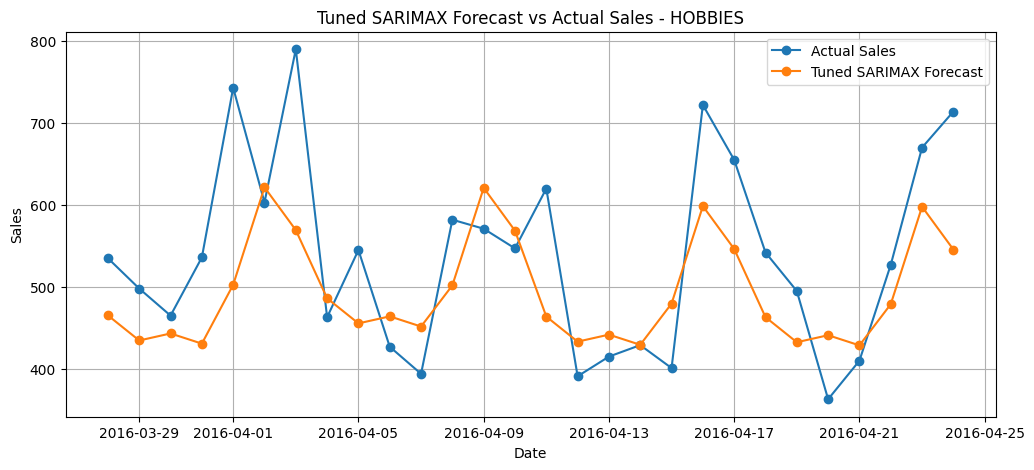

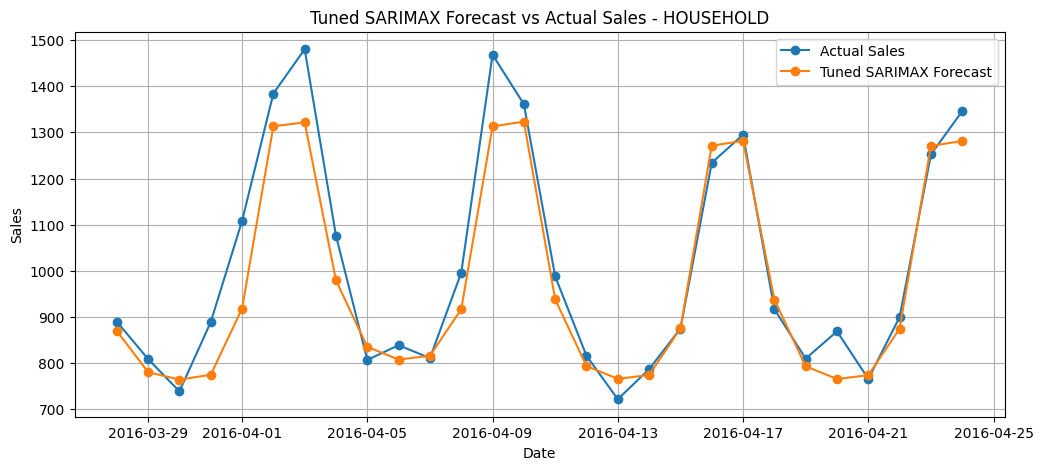

In [68]:
for category in final_all_category_forecasts_df["category"].unique():
    temp_df = final_all_category_forecasts_df[
        final_all_category_forecasts_df["category"] == category
    ]
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(
        temp_df["date"],
        temp_df["actual_sales"],
        label="Actual Sales",
        marker="o"
    )
    
    plt.plot(
        temp_df["date"],
        temp_df["sarimax_forecast"],
        label="Tuned SARIMAX Forecast",
        marker="o"
    )
    
    plt.title(f"Tuned SARIMAX Forecast vs Actual Sales - {category}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()

In [69]:
all_tuned_results_path = os.path.join(
    OUTPUTS_DIR,
    "all_category_tuned_sarimax_results_CA_1.csv"
)

all_tuned_forecasts_path = os.path.join(
    OUTPUTS_DIR,
    "all_category_tuned_sarimax_forecasts_CA_1.csv"
)

all_tuned_results_df.to_csv(all_tuned_results_path, index=False)
final_all_category_forecasts_df.to_csv(all_tuned_forecasts_path, index=False)

print("Tuned results saved to:")
print(all_tuned_results_path)

print("\nTuned forecasts saved to:")
print(all_tuned_forecasts_path)

Tuned results saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\all_category_tuned_sarimax_results_CA_1.csv

Tuned forecasts saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\all_category_tuned_sarimax_forecasts_CA_1.csv


In [70]:
for category, model_result in all_tuned_models.items():
    model_path = os.path.join(
        MODELS_DIR,
        f"best_sarimax_{category.lower()}_CA_1.pkl"
    )
    
    joblib.dump(model_result, model_path)
    
    print(f"Saved {category} model to:")
    print(model_path)

Saved FOODS model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_foods_CA_1.pkl
Saved HOBBIES model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_hobbies_CA_1.pkl
Saved HOUSEHOLD model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_household_CA_1.pkl


## 18. Improved SARIMAX with Calendar-Based Exogenous Features

The previous SARIMAX model used only `snap_CA` as an external variable.

To improve the model, especially for lower-volume categories like HOBBIES, we add more calendar-based features:

- SNAP day indicator
- weekday dummy variables
- month dummy variables
- event indicator

These features help the model understand business patterns beyond pure sales history.

In [76]:
category_daily_enriched_df = (
    store_sales_long_df
    .groupby(["date", "cat_id"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        snap_CA=("snap_CA", "max"),
        weekday=("weekday", "first"),
        month=("month", "first"),
        event_name_1=("event_name_1", "first"),
        event_type_1=("event_type_1", "first")
    )
)

category_daily_enriched_df["is_event"] = (
    category_daily_enriched_df["event_name_1"]
    .notna()
    .astype(int)
)

print("Enriched category daily shape:", category_daily_enriched_df.shape)

category_daily_enriched_df.head()

Enriched category daily shape: (5739, 9)


,date,cat_id,sales,snap_CA,weekday,month,event_name_1,event_type_1,is_event
0,2011-01-29,FOODS,3239,0,Saturday,1,NaN,NaN,0
1,2011-01-29,HOBBIES,556,0,Saturday,1,NaN,NaN,0
2,2011-01-29,HOUSEHOLD,542,0,Saturday,1,NaN,NaN,0
3,2011-01-30,FOODS,3137,0,Sunday,1,NaN,NaN,0
4,2011-01-30,HOBBIES,498,0,Sunday,1,NaN,NaN,0


In [77]:
def prepare_category_timeseries_with_features(category_daily_enriched_df, category_name):
    """
    Prepare daily category time series with numeric exogenous calendar features.
    """
    category_df = category_daily_enriched_df[
        category_daily_enriched_df["cat_id"] == category_name
    ].copy()
    
    category_df = category_df.sort_values("date")
    
    category_ts = category_df[
        ["date", "sales", "snap_CA", "weekday", "month", "is_event"]
    ].copy()
    
    category_ts = category_ts.set_index("date")
    category_ts = category_ts.asfreq("D")
    
    weekday_dummies = pd.get_dummies(
        category_ts["weekday"],
        prefix="weekday",
        drop_first=True,
        dtype=int
    )
    
    month_dummies = pd.get_dummies(
        category_ts["month"].astype(str),
        prefix="month",
        drop_first=True,
        dtype=int
    )
    
    category_ts = pd.concat(
        [
            category_ts[["sales", "snap_CA", "is_event"]],
            weekday_dummies,
            month_dummies
        ],
        axis=1
    )
    
    category_ts = category_ts.fillna(0)
    
    # SARIMAX needs all exogenous columns to be numeric
    category_ts = category_ts.apply(pd.to_numeric, errors="coerce").fillna(0)
    category_ts = category_ts.astype(float)
    
    return category_ts

In [78]:
test_ts = prepare_category_timeseries_with_features(
    category_daily_enriched_df=category_daily_enriched_df,
    category_name="FOODS"
)

print(test_ts.shape)
print(test_ts.dtypes)

test_ts.head()

(1913, 20)
sales                float64
snap_CA              float64
is_event             float64
weekday_Monday       float64
weekday_Saturday     float64
weekday_Sunday       float64
weekday_Thursday     float64
weekday_Tuesday      float64
weekday_Wednesday    float64
month_10             float64
month_11             float64
month_12             float64
month_2              float64
month_3              float64
month_4              float64
month_5              float64
month_6              float64
month_7              float64
month_8              float64
month_9              float64
dtype: object


,sales,snap_CA,is_event,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
date,,,,,,,,,,,,,,,,,,,,
2011-01-29,3239.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-30,3137.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-31,2008.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-01,2258.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-02,2032.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
def run_category_sarimax_with_calendar_features(
    category_daily_enriched_df,
    category_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX with SNAP + weekday + month + event features.
    """
    
    category_ts = prepare_category_timeseries_with_features(
        category_daily_enriched_df=category_daily_enriched_df,
        category_name=category_name
    )
    
    train_data = category_ts.iloc[:-forecast_horizon].copy()
    test_data = category_ts.iloc[-forecast_horizon:].copy()
    
    y_train_cat = train_data["sales"]
    y_test_cat = test_data["sales"]
    
    X_train_cat = train_data.drop(columns=["sales"])
    X_test_cat = test_data.drop(columns=["sales"])
    
    model = SARIMAX(
        y_train_cat,
        exog=X_train_cat,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_cat
    )
    
    forecast_values = forecast_result.predicted_mean
    
    metrics = evaluate_forecast(
        y_true=y_test_cat.values,
        y_pred=forecast_values.values,
        model_name=f"Calendar SARIMAX {order}{seasonal_order} - {category_name}"
    )
    
    metrics["category"] = category_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_weekday_month_event"
    
    forecast_df = pd.DataFrame({
        "date": y_test_cat.index,
        "category": category_name,
        "actual_sales": y_test_cat.values,
        "calendar_sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [80]:
def tune_calendar_sarimax_for_category(
    category_daily_enriched_df,
    category_name,
    configs,
    forecast_horizon=28
):
    """
    Tune calendar-feature SARIMAX models for one category.
    """
    
    category_results = []
    category_models = {}
    category_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"Calendar SARIMAX {order}{seasonal_order} - {category_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_category_sarimax_with_calendar_features(
                category_daily_enriched_df=category_daily_enriched_df,
                category_name=category_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            category_results.append(metrics)
            category_models[model_label] = model_result
            category_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    category_results_df = pd.DataFrame(category_results)
    
    if category_results_df.empty:
        return category_results_df, category_models, category_forecasts
    
    category_results_df = category_results_df.sort_values("MAPE")
    
    return category_results_df, category_models, category_forecasts

In [81]:
all_calendar_tuned_results = []
all_calendar_tuned_models = {}
all_calendar_tuned_forecasts = {}

for category in all_categories:
    print("=" * 70)
    print("Calendar feature tuning for category:", category)
    print("=" * 70)
    
    category_results_df, category_models, category_forecasts = tune_calendar_sarimax_for_category(
        category_daily_enriched_df=category_daily_enriched_df,
        category_name=category,
        configs=category_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if category_results_df.empty:
        print("No successful model for:", category)
        continue
    
    best_row = category_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_calendar_tuned_results.append(best_row)
    all_calendar_tuned_models[category] = category_models[best_model_label]
    all_calendar_tuned_forecasts[category] = category_forecasts[best_model_label]
    
    print("Best calendar model for", category)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Calendar feature tuning for category: FOODS
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS
MAPE: 4.87 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS
Done: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS
MAPE: 4.32 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS
Done: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS
MAPE: 10.1 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS
Done: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS
MAPE: 5.96 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS
MAPE: 8.59 %
Converged: True
--------------------------------------------------
Traini

c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - HOBBIES
MAPE: 15.53 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBIES


c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBIES
MAPE: 19.47 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - HOBBIES


...

Done: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - HOUSEHOLD
MAPE: 6.66 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD


c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD
MAPE: 6.36 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - HOUSEHOLD


c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - HOUSEHOLD
MAPE: 8.56 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOUSEHOLD
Done: Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOUSEHOLD
MAPE: 6.68 %
Converged: True
--------------------------------------------------
Best calendar model for HOUSEHOLD
Model: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD
MAPE: 6.36 %



In [82]:
all_calendar_tuned_results_df = pd.DataFrame(all_calendar_tuned_results)

all_calendar_tuned_results_df = all_calendar_tuned_results_df[
    [
        "category",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_calendar_tuned_results_df

,category,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
1,FOODS,"Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS",snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",128.502108,160.717613,4.317984,27210.368450,True
3,HOUSEHOLD,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSE...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",67.473801,89.687432,6.363999,22139.806636,False
5,HOBBIES,"Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBIES",snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",80.055890,90.381056,15.396759,22067.163877,False


## 19. Feature Experiment Comparison

We tested two SARIMAX feature setups:

1. SNAP-only SARIMAX
2. Calendar-feature SARIMAX using SNAP, weekday, month, and event indicators

Although calendar features added more information, they did not improve validation accuracy.  
The calendar-feature models also caused convergence issues for HOUSEHOLD and HOBBIES.

Therefore, the simpler SNAP-only SARIMAX model is selected as the final model.

In [83]:
snap_only_results_df = all_tuned_results_df.copy()
snap_only_results_df["feature_set"] = "snap_only"

calendar_results_df = all_calendar_tuned_results_df.copy()

feature_comparison_df = pd.concat(
    [
        snap_only_results_df[
            ["category", "feature_set", "order", "seasonal_order", "MAE", "RMSE", "MAPE", "AIC", "converged"]
        ],
        calendar_results_df[
            ["category", "feature_set", "order", "seasonal_order", "MAE", "RMSE", "MAPE", "AIC", "converged"]
        ]
    ],
    ignore_index=True
)

feature_comparison_df = feature_comparison_df.sort_values(["category", "MAPE"])

feature_comparison_df

,category,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS,snap_only,"(1, 1, 1)","(1, 1, 1, 7)",119.953486,148.827865,4.096004,26697.407221,True
3,FOODS,snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",128.502108,160.717613,4.317984,27210.368450,True
2,HOBBIES,snap_only,"(0, 1, 1)","(0, 1, 1, 7)",77.200629,96.805784,13.469932,22035.004708,True
5,HOBBIES,snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",80.055890,90.381056,15.396759,22067.163877,False
1,HOUSEHOLD,snap_only,"(1, 1, 1)","(1, 1, 1, 7)",52.753027,72.495923,4.964332,22086.522849,True
4,HOUSEHOLD,snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",67.473801,89.687432,6.363999,22139.806636,False


In [84]:
final_selected_models_df = (
    feature_comparison_df
    .sort_values(["category", "MAPE"])
    .groupby("category", as_index=False)
    .first()
)

final_selected_models_df

,category,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS,snap_only,"(1, 1, 1)","(1, 1, 1, 7)",119.953486,148.827865,4.096004,26697.407221,True
1,HOBBIES,snap_only,"(0, 1, 1)","(0, 1, 1, 7)",77.200629,96.805784,13.469932,22035.004708,True
2,HOUSEHOLD,snap_only,"(1, 1, 1)","(1, 1, 1, 7)",52.753027,72.495923,4.964332,22086.522849,True


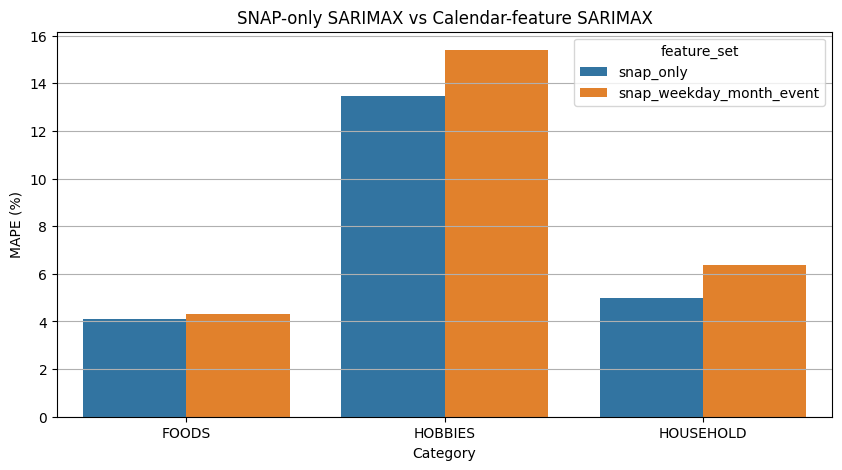

In [85]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=feature_comparison_df,
    x="category",
    y="MAPE",
    hue="feature_set"
)

plt.title("SNAP-only SARIMAX vs Calendar-feature SARIMAX")
plt.xlabel("Category")
plt.ylabel("MAPE (%)")
plt.grid(axis="y")
plt.show()

In [86]:
feature_comparison_path = os.path.join(
    OUTPUTS_DIR,
    "feature_comparison_sarimax_CA_1.csv"
)

final_selected_models_path = os.path.join(
    OUTPUTS_DIR,
    "final_selected_models_CA_1.csv"
)

feature_comparison_df.to_csv(feature_comparison_path, index=False)
final_selected_models_df.to_csv(final_selected_models_path, index=False)

print("Feature comparison saved to:")
print(feature_comparison_path)

print("\nFinal selected models saved to:")
print(final_selected_models_path)

Feature comparison saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\feature_comparison_sarimax_CA_1.csv

Final selected models saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_selected_models_CA_1.csv


## 20. Final Conclusion

This notebook built a category-level demand forecasting pipeline for Walmart store CA_1 using the M5 dataset.

The workflow started from raw item-level sales data, converted it into long format, aggregated sales at the category level, and trained SARIMAX models for 28-day demand forecasting.

The final selected models were SNAP-only SARIMAX models because they achieved lower validation error and better convergence stability compared to calendar-feature SARIMAX models.

### Final Model Performance

- FOODS achieved the best performance with a MAPE of around 4.10%.
- HOUSEHOLD also performed strongly with a MAPE of around 4.96%.
- HOBBIES had a higher MAPE of around 13.47%, mainly because it has lower sales volume and more irregular demand spikes.

### Business Takeaways

1. FOODS should be treated as the highest-priority category because it has the highest demand volume.
2. Weekly seasonality is important for all categories and should be considered in inventory planning.
3. SNAP days are useful external signals for demand forecasting.
4. Adding weekday, month, and event features did not improve this SARIMAX setup, so the simpler SNAP-only model was selected.
5. HOBBIES requires further improvement using price, promotion, event, or item-level features.

In [87]:
final_notebook_summary = {
    "store": SELECTED_STORE,
    "forecast_level": "category",
    "forecast_horizon_days": FORECAST_HORIZON,
    "final_feature_set": "snap_only",
    "best_foods_mape": final_selected_models_df.loc[
        final_selected_models_df["category"] == "FOODS", "MAPE"
    ].values[0],
    "best_hobbies_mape": final_selected_models_df.loc[
        final_selected_models_df["category"] == "HOBBIES", "MAPE"
    ].values[0],
    "best_household_mape": final_selected_models_df.loc[
        final_selected_models_df["category"] == "HOUSEHOLD", "MAPE"
    ].values[0],
}

final_notebook_summary_df = pd.DataFrame([final_notebook_summary])

final_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_category_forecasting_summary_CA_1.csv"
)

final_notebook_summary_df.to_csv(final_summary_path, index=False)

print("Final category forecasting summary saved to:")
print(final_summary_path)

final_notebook_summary_df

Final category forecasting summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_category_forecasting_summary_CA_1.csv


,store,forecast_level,forecast_horizon_days,final_feature_set,best_foods_mape,best_hobbies_mape,best_household_mape
0,CA_1,category,28,snap_only,4.096004,13.469932,4.964332
